# Tutorial: Milestone 3 - MISA Fusion

Audience:
- You've completed Milestone 2 (real audio/video, concatenation fusion) and know that naive
  concatenation let dense audio/video embeddings dominate the classifier, hurting accuracy.

Prerequisites:
- Run `python src/misa_model.py` (a quick smoke test) and `python src/train_misa.py` at least once first
  -- this notebook imports the model class from `src/misa_model.py` rather than redefining it.

Learning goals:
- By the end, you can explain what 'shared' vs. 'private' modality representations are, why MISA's
  auxiliary losses exist, and read a training curve (the first one in this project -- everything
  before this milestone trained instantly, with nothing to plot over time).

**What's new here:** this is the first REAL gradient-based training in the project (a small neural
network, trained with backpropagation) rather than fitting a linear classifier on frozen features.
It's also the first time the `val` split actually gets used (for early stopping) instead of just
being computed and set aside.


## Outline

1. Setup
2. Step 1 - Load the real MIntRec multimodal index (same data as Milestone 2)
3. Step 2 - Split into train / validation / test
4. Step 3 - The MISA architecture, in plain language
5. Step 4 - Train, with early stopping on validation macro-F1
6. Training curves
7. Step 5 - Evaluate, and compare against Milestone 2
8. Look at the mistakes
9. Exercises
10. Pitfalls and extensions


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from misa_model import MISAModel, misa_loss  # the reviewed model class -- not redefined here

INDEX_PATH = PROJECT_ROOT / "data" / "mintrec_multimodal" / "index.csv"
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "mintrec_multimodal" / "embeddings"
RESULTS_DIR = PROJECT_ROOT / "results"
INDEX_PATH


WindowsPath('C:/Users/dbest/Downloads/multimodal-intent-inference/multimodal-intent-inference/data/mintrec_multimodal/index.csv')

## Step 1 - Load the real MIntRec multimodal index

Identical data source to Milestone 2 -- the same 300-clip subset, same embeddings. Only the fusion
method changes in this notebook.


In [2]:
df = pd.read_csv(INDEX_PATH)
print(f"Loaded {len(df)} samples from {INDEX_PATH.name}")
df["intent"].value_counts()


Loaded 300 samples from index.csv


intent
Advise          15
Agree           15
Apologise       15
Arrange         15
Ask for help    15
Care            15
Comfort         15
Complain        15
Criticize       15
Flaunt          15
Greet           15
Inform          15
Introduce       15
Joke            15
Leave           15
Oppose          15
Praise          15
Prevent         15
Taunt           15
Thank           15
Name: count, dtype: int64

## Step 2 - Split into train / validation / test

Same split as every prior script -- but this time `val` actually gets used, for early stopping below.


In [3]:
train_val, test = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["intent"]
)
train, val = train_test_split(
    train_val, test_size=0.1875, random_state=42, stratify=train_val["intent"]
)
print(f"train: {len(train)} samples")
print(f"val:   {len(val)} samples  (used for early stopping this time)")
print(f"test:  {len(test)} samples")


train: 195 samples
val:   45 samples  (used for early stopping this time)
test:  60 samples


## Step 3 - The MISA architecture, in plain language

Milestone 2's fusion was `np.hstack([text, audio, video])` -- glue the three feature vectors end to end.
That let audio/video's much larger raw magnitude dominate the classifier even after scaling.

MISA instead learns, for each modality, two separate representations:
- **Shared** ("modality-invariant"): the exact same projection (same weights) is applied to text,
  audio, and video -- encouraging all three to land in a common, comparable space.
- **Private** ("modality-specific"): a separate projection per modality, capturing what's unique to it.

Three extra loss terms (beyond the usual classification loss) shape these during training:
- **Similarity loss** -- pulls the three SHARED representations toward each other.
- **Difference loss** -- pushes each PRIVATE representation away from its own SHARED representation
  and away from other modalities' PRIVATE representations, so they don't just duplicate each other.
- **Reconstruction loss** -- shared+private together must be able to reconstruct the original encoded
  representation, checking that splitting into shared/private didn't throw information away.

Finally, all six representations (3 shared + 3 private) go through one self-attention layer -- so each
can be influenced by the others -- before a final linear classifier.

See `src/misa_model.py` for the full implementation (imported above, not re-shown here since the
reviewed, tested version already lives in one place).


In [4]:
# Peek at the model's structure and size.
model_preview = MISAModel(text_dim=1000, num_classes=20)  # text_dim is a placeholder just to inspect shape
n_params = sum(p.numel() for p in model_preview.parameters())
print(model_preview)
print(f"\nTotal trainable parameters: {n_params:,}")


MISAModel(
  (text_encoder): Sequential(
    (0): Linear(in_features=1000, out_features=128, bias=True)
    (1): ReLU()
  )
  (audio_encoder): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
  )
  (video_encoder): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
  )
  (shared_proj): Linear(in_features=128, out_features=128, bias=True)
  (private_text_proj): Linear(in_features=128, out_features=128, bias=True)
  (private_audio_proj): Linear(in_features=128, out_features=128, bias=True)
  (private_video_proj): Linear(in_features=128, out_features=128, bias=True)
  (decoder): Linear(in_features=256, out_features=128, bias=True)
  (fusion_layer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_feat

## Step 4 - Train, with early stopping on validation macro-F1

Unlike every prior milestone (which fit instantly), this is real iterative training: the model sees
the training data many times (epochs), and we watch validation performance to know when to stop --
training longer isn't always better, since the model can start memorizing the training set instead of
learning generalizable patterns.


In [5]:
def build_audio_features(frame_df):
    return np.array([np.load(EMBEDDINGS_DIR / f"{sid}.npz")["audio"] for sid in frame_df["sample_id"]])


def build_video_features(frame_df):
    return np.array([np.load(EMBEDDINGS_DIR / f"{sid}.npz")["video"] for sid in frame_df["sample_id"]])


tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
text_train = tfidf.fit_transform(train["text"]).toarray().astype(np.float32)
text_val = tfidf.transform(val["text"]).toarray().astype(np.float32)
text_test = tfidf.transform(test["text"]).toarray().astype(np.float32)

audio_train, audio_val, audio_test = (build_audio_features(d).astype(np.float32) for d in (train, val, test))
video_train, video_val, video_test = (build_video_features(d).astype(np.float32) for d in (train, val, test))

labels_sorted = sorted(df["intent"].unique())
label2id = {name: i for i, name in enumerate(labels_sorted)}
id2label = {i: name for name, i in label2id.items()}


def to_tensors(text, audio, video, labels):
    return (
        torch.from_numpy(text), torch.from_numpy(audio), torch.from_numpy(video),
        torch.tensor([label2id[l] for l in labels], dtype=torch.long),
    )


text_train_t, audio_train_t, video_train_t, labels_train_t = to_tensors(text_train, audio_train, video_train, train["intent"].tolist())
text_val_t, audio_val_t, video_val_t, labels_val_t = to_tensors(text_val, audio_val, video_val, val["intent"].tolist())
text_test_t, audio_test_t, video_test_t, labels_test_t = to_tensors(text_test, audio_test, video_test, test["intent"].tolist())
print(f"Fused input: text={text_train.shape[1]}-dim, audio=768-dim, video=512-dim")


Fused input: text=1426-dim, audio=768-dim, video=512-dim


In [6]:
import copy

HIDDEN_DIM, BATCH_SIZE, MAX_EPOCHS, PATIENCE, LEARNING_RATE, SEED = 128, 16, 100, 15, 1e-3, 0


def run_epoch(model, optimizer, text, audio, video, labels, batch_size, train_mode):
    model.train(train_mode)
    n = text.shape[0]
    indices = torch.randperm(n) if train_mode else torch.arange(n)
    total_loss = 0.0
    all_preds, all_labels = [], []
    for start in range(0, n, batch_size):
        batch_idx = indices[start:start + batch_size]
        bt, ba, bv, bl = text[batch_idx], audio[batch_idx], video[batch_idx], labels[batch_idx]
        if train_mode:
            optimizer.zero_grad()
            logits, reps = model(bt, ba, bv)
            loss, _ = misa_loss(logits, bl, reps)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                logits, reps = model(bt, ba, bv)
                loss, _ = misa_loss(logits, bl, reps)
        total_loss += loss.item() * len(batch_idx)
        all_preds.extend(logits.argmax(dim=1).tolist())
        all_labels.extend(bl.tolist())
    avg_loss = total_loss / n
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, macro_f1


torch.manual_seed(SEED)
model = MISAModel(text_dim=text_train.shape[1], hidden_dim=HIDDEN_DIM, num_classes=20)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1, best_state, epochs_without_improvement = -1.0, None, 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_f1 = run_epoch(model, optimizer, text_train_t, audio_train_t, video_train_t, labels_train_t, BATCH_SIZE, True)
    val_loss, val_f1 = run_epoch(model, optimizer, text_val_t, audio_val_t, video_val_t, labels_val_t, BATCH_SIZE, False)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1); history["val_f1"].append(val_f1)

    improved = val_f1 > best_val_f1
    if improved:
        best_val_f1, best_state, epochs_without_improvement = val_f1, copy.deepcopy(model.state_dict()), 0
    else:
        epochs_without_improvement += 1
    if epoch <= 5 or epoch % 10 == 0 or improved:
        marker = " *" if improved else ""
        print(f"epoch {epoch:3d}  train_loss={train_loss:.4f} train_f1={train_f1:.3f}  val_loss={val_loss:.4f} val_f1={val_f1:.3f}{marker}")
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).")
        break
else:
    print(f"\nReached max epochs ({MAX_EPOCHS}) without early stopping.")

model.load_state_dict(best_state)
print(f"Restored best checkpoint (val macro-F1={best_val_f1:.3f}).")


epoch   1  train_loss=3.2682 train_f1=0.017  val_loss=3.1003 val_f1=0.026 *
epoch   2  train_loss=2.9666 train_f1=0.065  val_loss=2.9623 val_f1=0.043 *


epoch   3  train_loss=2.7348 train_f1=0.177  val_loss=2.8902 val_f1=0.068 *
epoch   4  train_loss=2.3278 train_f1=0.434  val_loss=2.9240 val_f1=0.072 *


epoch   5  train_loss=1.7620 train_f1=0.744  val_loss=2.6516 val_f1=0.220 *
epoch   6  train_loss=1.1280 train_f1=0.953  val_loss=2.5794 val_f1=0.228 *


epoch   7  train_loss=0.6439 train_f1=1.000  val_loss=2.4857 val_f1=0.316 *
epoch   8  train_loss=0.3186 train_f1=1.000  val_loss=2.7011 val_f1=0.323 *


epoch  10  train_loss=0.0885 train_f1=1.000  val_loss=2.6823 val_f1=0.277
epoch  11  train_loss=0.0576 train_f1=1.000  val_loss=2.5921 val_f1=0.345 *


epoch  20  train_loss=0.0136 train_f1=1.000  val_loss=2.7514 val_f1=0.333



Early stopping at epoch 26 (no val improvement for 15 epochs).
Restored best checkpoint (val macro-F1=0.345).


## Training curves

This is the first plot of its kind in this project -- everything before Milestone 3 trained instantly,
with no "progress over time" to show. Watch for: train loss should generally decrease; val loss
decreasing alongside it is good, val loss going back up while train loss keeps dropping is the
textbook overfitting signature (not necessarily what happens here -- read the actual curve).


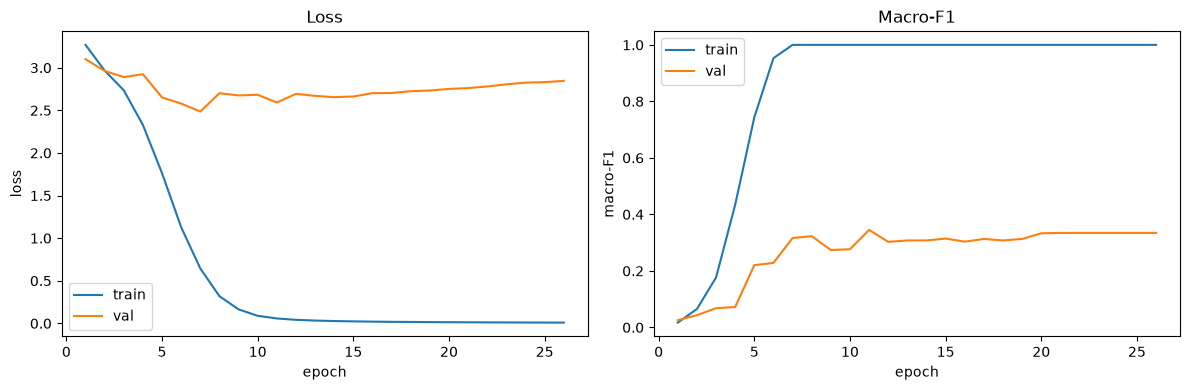

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_ran = range(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs_ran, history["train_loss"], label="train")
axes[0].plot(epochs_ran, history["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs_ran, history["train_f1"], label="train")
axes[1].plot(epochs_ran, history["val_f1"], label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro-F1"); axes[1].set_title("Macro-F1"); axes[1].legend()
fig.tight_layout()
plt.show()


**What this run actually shows:** the textbook overfitting signature, unambiguously. Train macro-F1
reaches 1.000 by epoch 7 -- the model has perfectly memorized all 195 training rows -- while validation
loss stops following it down and drifts back up (2.49 at epoch 7, 2.70 at epoch 8, 2.75 by epoch 20).
Validation macro-F1 wobbles around 0.28-0.35 instead of tracking the train curve upward. That divergence
is exactly why early stopping restores the best checkpoint rather than the final one: the last epoch's
weights score strictly worse on the validation split than epoch 11's did.

## Step 5 - Evaluate, and compare against Milestone 2


In [8]:
model.eval()
with torch.no_grad():
    logits, _ = model(text_test_t, audio_test_t, video_test_t)
preds = [id2label[p] for p in logits.argmax(dim=1).tolist()]
truth = [id2label[l] for l in labels_test_t.tolist()]

acc = accuracy_score(truth, preds)
macro_f1 = f1_score(truth, preds, average="macro", zero_division=0)
print(f"Accuracy : {acc:.3f}")
print(f"Macro-F1 : {macro_f1:.3f}")


Accuracy : 0.333
Macro-F1 : 0.295


In [9]:
print(classification_report(truth, preds, zero_division=0))


              precision    recall  f1-score   support

      Advise       0.00      0.00      0.00         3
       Agree       0.50      0.67      0.57         3
   Apologise       0.75      1.00      0.86         3
     Arrange       0.00      0.00      0.00         3
Ask for help       0.29      0.67      0.40         3
        Care       0.50      1.00      0.67         3
     Comfort       0.00      0.00      0.00         3
    Complain       0.00      0.00      0.00         3
   Criticize       0.00      0.00      0.00         3
      Flaunt       0.00      0.00      0.00         3
       Greet       0.60      1.00      0.75         3
      Inform       1.00      0.33      0.50         3
   Introduce       1.00      0.67      0.80         3
        Joke       0.00      0.00      0.00         3
       Leave       0.00      0.00      0.00         3
      Oppose       1.00      0.33      0.50         3
      Praise       0.00      0.00      0.00         3
     Prevent       0.00    

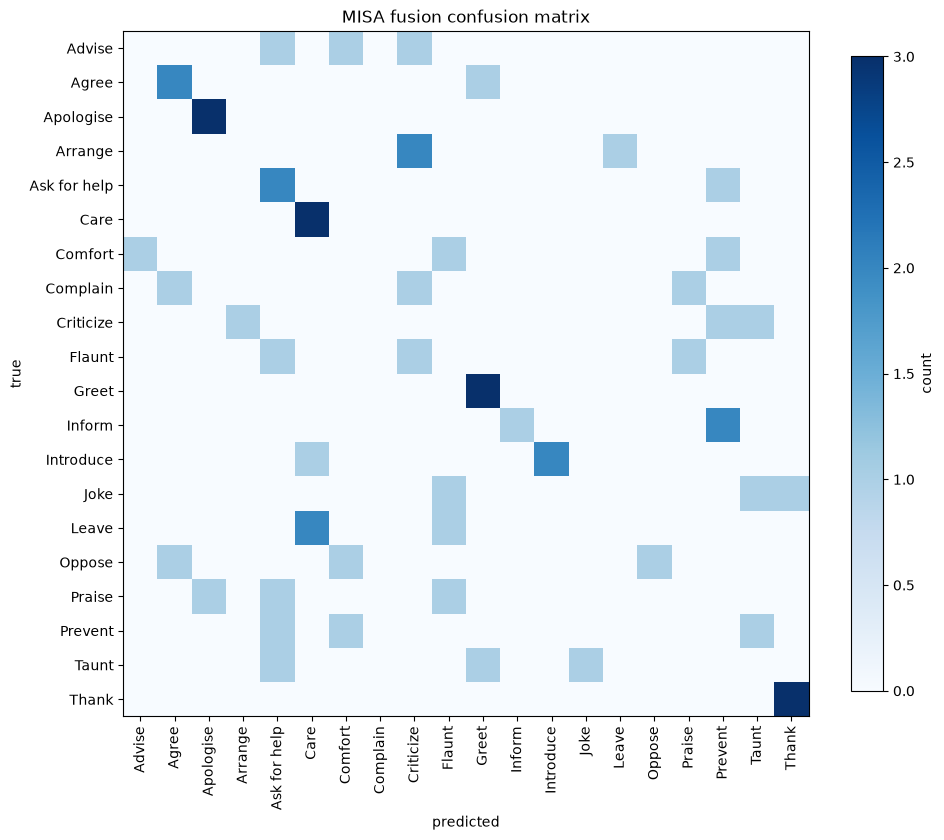

In [10]:
labels_present = sorted(set(truth) | set(preds))
cm = confusion_matrix(truth, preds, labels=labels_present)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_present)), labels_present, rotation=90)
ax.set_yticks(range(len(labels_present)), labels_present)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("MISA fusion confusion matrix")
fig.colorbar(im, ax=ax, shrink=0.8, label="count")
fig.tight_layout()
plt.show()


### A controlled check: is it the shared/private split, or just having a neural network?

Before crediting MISA's shared/private decomposition for the improvement, note what else changed
between Milestone 2 and here: M2 fit a *linear* classifier on frozen, hand-scaled features, while this
milestone trains a *neural network* that learns its own per-modality projections. Those are two
different changes bundled into one comparison.

The cell below isolates them. It keeps the exact same per-modality MLP encoders MISA uses, but sends
their outputs straight into the classifier via plain `torch.cat` -- no shared/private projections, no
reconstruction decoder, no self-attention fusion, no auxiliary losses. Everything else (features,
split, batch size, learning rate, early stopping) is held fixed. Three seeds, because a single run
can't tell signal from luck on 60 test samples.

In [11]:
import torch.nn as nn
from torch.nn.functional import cross_entropy


class PlainConcatModel(nn.Module):
    """MISA's per-modality MLP encoders, with everything MISA-specific removed."""

    def __init__(self, text_dim, audio_dim=768, video_dim=512, hidden_dim=128, num_classes=20):
        super().__init__()
        self.text_encoder = nn.Sequential(nn.Linear(text_dim, hidden_dim), nn.ReLU())
        self.audio_encoder = nn.Sequential(nn.Linear(audio_dim, hidden_dim), nn.ReLU())
        self.video_encoder = nn.Sequential(nn.Linear(video_dim, hidden_dim), nn.ReLU())
        self.classifier = nn.Linear(3 * hidden_dim, num_classes)

    def forward(self, t, a, v):
        fused = torch.cat([self.text_encoder(t), self.audio_encoder(a), self.video_encoder(v)], dim=-1)
        return self.classifier(fused)


def run_plain_epoch(m, opt, text, audio, video, labels, train_mode):
    m.train(train_mode)
    n = text.shape[0]
    indices = torch.randperm(n) if train_mode else torch.arange(n)
    preds_all, labels_all = [], []
    for start in range(0, n, BATCH_SIZE):
        idx = indices[start:start + BATCH_SIZE]
        bt, ba, bv, bl = text[idx], audio[idx], video[idx], labels[idx]
        if train_mode:
            opt.zero_grad()
            out = m(bt, ba, bv)
            cross_entropy(out, bl).backward()
            opt.step()
        else:
            with torch.no_grad():
                out = m(bt, ba, bv)
        preds_all.extend(out.argmax(dim=1).tolist())
        labels_all.extend(bl.tolist())
    return f1_score(labels_all, preds_all, average="macro", zero_division=0)


plain_accs, plain_f1s = [], []
for seed in (0, 1, 2):
    torch.manual_seed(seed)
    plain = PlainConcatModel(text_dim=text_train.shape[1], hidden_dim=HIDDEN_DIM, num_classes=20)
    plain_opt = torch.optim.Adam(plain.parameters(), lr=LEARNING_RATE)
    best_f1, best_sd, stale = -1.0, None, 0
    for _ in range(MAX_EPOCHS):
        run_plain_epoch(plain, plain_opt, text_train_t, audio_train_t, video_train_t, labels_train_t, True)
        val_f1_plain = run_plain_epoch(plain, plain_opt, text_val_t, audio_val_t, video_val_t, labels_val_t, False)
        if val_f1_plain > best_f1:
            best_f1, best_sd, stale = val_f1_plain, copy.deepcopy(plain.state_dict()), 0
        else:
            stale += 1
            if stale >= PATIENCE:
                break
    plain.load_state_dict(best_sd)
    plain.eval()
    with torch.no_grad():
        plain_preds = plain(text_test_t, audio_test_t, video_test_t).argmax(dim=1).tolist()
    plain_truth = labels_test_t.tolist()
    plain_accs.append(accuracy_score(plain_truth, plain_preds))
    plain_f1s.append(f1_score(plain_truth, plain_preds, average="macro", zero_division=0))
    print(f"seed {seed}:  accuracy={plain_accs[-1]:.3f}  macro-F1={plain_f1s[-1]:.3f}")

plain_acc, plain_f1 = float(np.mean(plain_accs)), float(np.mean(plain_f1s))
print(f"\nplain-concat mean over 3 seeds:  accuracy={plain_acc:.3f}  macro-F1={plain_f1:.3f}")

seed 0:  accuracy=0.333  macro-F1=0.289


seed 1:  accuracy=0.267  macro-F1=0.255


seed 2:  accuracy=0.250  macro-F1=0.238

plain-concat mean over 3 seeds:  accuracy=0.283  macro-F1=0.261


### Compare against Milestone 2's concatenation fusion


In [12]:
comparison = pd.DataFrame([
    {"model": "Text-only (M2 ablation: LogReg on TF-IDF, no scaler)", "accuracy": 0.383, "macro_f1": 0.347},
    {"model": "Concatenation fusion (M2: LogReg + StandardScaler)", "accuracy": 0.117, "macro_f1": 0.096},
    {"model": "Plain concat over MLP encoders (mean of 3 seeds, above)", "accuracy": plain_acc, "macro_f1": plain_f1},
    {"model": "MISA fusion (M3, this run, SEED=0)", "accuracy": acc, "macro_f1": macro_f1},
]).set_index("model")
comparison

,accuracy,macro_f1
model,,
"Text-only (M2 ablation: LogReg on TF-IDF, no scaler)",0.383000,0.347000
Concatenation fusion (M2: LogReg + StandardScaler),0.117000,0.096000
"Plain concat over MLP encoders (mean of 3 seeds, above)",0.283333,0.260622
"MISA fusion (M3, this run, SEED=0)",0.333333,0.295119


**Interpretation:** replacing Milestone 2's linear-classifier-on-frozen-features with a trainable neural
fusion network recovered most of the ground concatenation fusion had lost: 0.117 -> 0.333 accuracy (roughly
a 3x improvement) and 0.096 -> 0.295 macro-F1.

Before crediting MISA's shared/private decomposition for that, look at the third row of the table. Plain
per-modality MLP encoders feeding a bare `torch.cat` into the classifier -- no shared/private split, no
self-attention fusion, no auxiliary losses -- already average 0.283 accuracy (0.333 / 0.267 / 0.250 across
seeds 0-2). That is about 0.17 of the 0.22-point climb from M2's 0.117 to this run's 0.333, roughly three
quarters of it, and none of it comes from MISA's actual mechanism. It is simply what happens when you swap
a linear classifier for *any* small trainable network that can learn its own per-modality scaling -- which
is the thing Milestone 2's `StandardScaler` was trying, and failing, to do by hand.

So the honest headline: **a trainable neural fusion network closed most of the gap that concatenation fusion
lost to modality-scale imbalance. How much of the rest is specifically MISA's shared/private decomposition,
versus simply having learned per-modality encoders at all, is untested by this notebook.** The 0.05 accuracy
separating MISA from the plain-concat control here is smaller than the run-to-run seed noise measured in
"Pitfalls and extensions" below, so it is suggestive at best. Settling it means holding everything else fixed
and toggling one component at a time over many seeds -- exactly the kind of controlled ablation Milestone 5
is for.

MISA also still trails the text-only baseline: 0.333 vs 0.383 accuracy, a gap of **5 percentage points**.
Plausible explanations, not mutually exclusive:

1. **Insufficient training data:** with only 195 training rows, the model may not have enough examples to
   learn a 6-way shared/private decomposition (3 shared + 3 private projections, plus three auxiliary loss
   terms) as effectively as a much simpler text-only classifier learns from the same data.
2. **Limited signal in audio/video:** audio and video may simply not carry discriminative intent information
   beyond what the transcript already captures in this domain. Milestone 2's single-modality ablation points
   the same way -- audio-only reached 0.067 accuracy and video-only 0.083, barely above chance.
3. **Auxiliary loss tuning:** the fixed similarity/difference/reconstruction weights may not suit this task
   (see the Exercises below).

Either way, this is a real and useful finding: on this 300-clip subset, adding audio and video did not beat
text alone, even with a fusion method designed specifically to handle modality-scale imbalance.

## Look at the mistakes


In [13]:
results_df = pd.DataFrame({"text": test["text"].tolist(), "true": truth, "predicted": preds})
mistakes = results_df[results_df["true"] != results_df["predicted"]]
print(f"{len(mistakes)} of {len(results_df)} test sentences were misclassified ({len(mistakes)/len(results_df):.1%}).")
mistakes.head(10)


40 of 60 test sentences were misclassified (66.7%).


,text,true,predicted
1,that guy's always making up stuff about people.,Criticize,Taunt
3,my official ordination license,Flaunt,Criticize
4,that's good advice.,Praise,Flaunt
7,"glenn, can i borrow $2,000 for sales tax?",Ask for help,Prevent
8,"uh, don't eat the baby food. the baby food is ...",Prevent,Taunt
9,i am going to sit in traffic for 45 minutes an...,Leave,Care
10,but really you were only using me to get to bo!,Criticize,Prevent
11,"so glenn, you're gonna be running care package...",Arrange,Criticize
12,"oh, no. it's not a game--",Oppose,Comfort
13,"glenn, it's--it's going to be okay.",Comfort,Advise


## Exercises

1. Try changing `sim_weight`/`diff_weight`/`recon_weight` in `src/misa_model.py`'s `misa_loss` call
   (edit the training loop above to pass different values) -- does emphasizing the auxiliary losses
   more or less change the result?
2. `HIDDEN_DIM = 128` above. Try a smaller value (e.g. 32) and a larger one (e.g. 256) -- with only 195
   training rows, does a bigger model actually help, or does it just overfit faster?


## Pitfalls and extensions

**Common mistake:** judging a fusion method from a single training run. Neural network training has real
run-to-run randomness (weight initialization, batch shuffling), and 60 test samples is a small target to
measure against. Rerunning the MISA training above with `SEED = 1` and `SEED = 2` gave test accuracies of
0.350 and 0.467 against this run's 0.333 -- a 13-point spread. The plain-concat control in the ablation cell
swung 0.250-0.333 over the same three seeds. Both spreads are *larger* than the 5-point MISA-vs-text-only gap
the interpretation above spends three paragraphs explaining, which is precisely why that discussion stays
hedged. Treat this milestone's number as one data point, not a verdict on MISA versus concatenation fusion.

**Extension:** this MISA adaptation uses simple MLP encoders and simplified similarity/difference
losses instead of the original paper's BiLSTM encoders and CMD loss -- see
`docs/superpowers/specs/2026-08-06-milestone3-misa-fusion-design.md` for exactly what was simplified
and why. A natural extension: scale up to the full 2,213-clip dataset (more training data might matter
more for a trainable fusion method than it did for M0-M2's frozen-feature approaches).